# 🐧 Many Penguins — a `chartcn` mini-project

A small showcase of [**chartcn**](https://pypi.org/project/chartcn/) — a
shadcn-inspired matplotlib wrapper for pandas DataFrames — using the
[TidyTuesday *Many Penguins*](https://github.com/rfordatascience/tidytuesday/tree/main/data/2026/2026-07-14)
dataset: morphometric measurements for **93 penguins across 18 species and 6 genera**
(drawn from the AVONET database).

The charts use chartcn's **bar, scatter, and histogram** types — each matched to the
shape of the question. (Line charts were tried first and dropped: this data has no
time or continuous x-axis, so a line implies a continuum between *categories* that
isn't real. See the note before the scatters.) Everything is styled with a custom
*penguin* theme (white, black, orange, gold) built entirely through chartcn's public
API — no changes to the package itself.


## Setup — imports and the penguin theme

In [1]:
%matplotlib inline
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import chartcn as viz

IMAGES = Path("images")
IMAGES.mkdir(exist_ok=True)

# A "penguin" palette — built with dataclasses.replace on the default LIGHT theme,
# so it keeps chartcn's shadcn chrome (rounded bars, no spines, faint grid) and just
# swaps in penguin colors: orange + black leading, with gold/amber accents.
penguin = replace(
    viz.LIGHT,
    name="penguin",
    categorical=(
        "#f97316",  # 1 orange (primary)
        "#1f2937",  # 2 near-black
        "#facc15",  # 3 gold
        "#f59e0b",  # 4 amber
        "#b45309",  # 5 dark amber
        "#fdba74",  # 6 light orange
        "#78716c",  # 7 warm gray
        "#fde68a",  # 8 pale yellow
    ),
    emphasis="#ea580c",    # deep orange for highlighted marks
    deemphasis="#d6d3d1",  # warm gray for the de-emphasized rest
    gridline="#efeae3",
)
viz.set_theme(penguin)  # use it for every chart below


def save(ax, name):
    """Save a chart into images/ (and let the inline backend display it)."""
    ax.figure.savefig(
        IMAGES / name, dpi=130, bbox_inches="tight", facecolor=penguin.surface
    )


## Load and clean the data

The raw CSV uses R-style dotted column names (`beak.length_culmen`,
`wing.length`, …) and terse codes for genus and sex. We:

1. rename the measurement columns to tidy `snake_case`,
2. map the six Latin genera to friendly common-group names,
3. spell out the `sex` codes (`M`/`F`/`U` → `Male`/`Female`/`Unknown`).

Missing values (`NaN`) are left in place — pandas' `groupby().mean()` skips them, so
each average uses whatever measurements are available.


In [2]:
raw = pd.read_csv("data/many_penguins.csv")

GENUS_NAME = {
    "Aptenodytes": "King & Emperor",
    "Pygoscelis": "Brush-tailed",
    "Eudyptes": "Crested",
    "Spheniscus": "Banded",
    "Eudyptula": "Little",
    "Megadyptes": "Yellow-eyed",
}
SEX_NAME = {"M": "Male", "F": "Female", "U": "Unknown"}

df = (
    raw.rename(
        columns={
            "beak.length_culmen": "beak_length",
            "beak.depth": "beak_depth",
            "beak.width": "beak_width",
            "wing.length": "wing_length",
            "tail.length": "tail_length",
            "tarsus.length": "tarsus_length",
        }
    )[
        [
            "species", "genus", "shortname", "sex",
            "beak_length", "beak_depth", "beak_width",
            "wing_length", "tail_length", "tarsus_length",
        ]
    ].copy()
)
df["group"] = df["genus"].map(GENUS_NAME)
df["sex"] = df["sex"].map(SEX_NAME)

# Genera ordered small -> large by mean wing length, reused to order some charts.
SIZE_ORDER = df.groupby("group")["wing_length"].mean().sort_values().index.tolist()
_rank = {g: i for i, g in enumerate(SIZE_ORDER)}


def by_size(frame):
    """Order a frame's rows by genus size (small -> large)."""
    return frame.sort_values("group", key=lambda s: s.map(_rank))


df.head()


,species,genus,shortname,sex,beak_length,beak_depth,beak_width,wing_length,tail_length,tarsus_length,group
0,Aptenodytes forsteri,Aptenodytes,A. forsteri,Unknown,66.8,17.9,13.0,170.0,111.0,NaN,King & Emperor
1,Aptenodytes forsteri,Aptenodytes,A. forsteri,Male,102.4,17.7,14.2,185.0,119.0,46.7,King & Emperor
2,Aptenodytes forsteri,Aptenodytes,A. forsteri,Male,103.7,16.3,13.7,180.0,120.0,45.7,King & Emperor
3,Aptenodytes forsteri,Aptenodytes,A. forsteri,Female,94.4,20.2,14.6,182.0,130.0,50.8,King & Emperor
4,Aptenodytes forsteri,Aptenodytes,A. forsteri,Female,103.7,16.6,13.8,180.0,107.5,45.8,King & Emperor


In [3]:
print(f"{len(df)} penguins · {df['species'].nunique()} species · {df['group'].nunique()} genera")
print("\nMissing values per measurement:")
df[["beak_length", "beak_depth", "beak_width",
    "wing_length", "tail_length", "tarsus_length"]].isna().sum()


93 penguins · 18 species · 6 genera

Missing values per measurement:


beak_length       0
beak_depth        1
beak_width        0
wing_length      14
tail_length       4
tarsus_length     9
dtype: int64

## Part 1 — comparing categories with bars

### 1 · Sample size per genus — counts, sorted, auto-labeled

Omitting `y` makes chartcn **count rows** per category. `sort="desc"` orders the bars,
and `label="auto"` labels only the tallest one — no number on every bar.


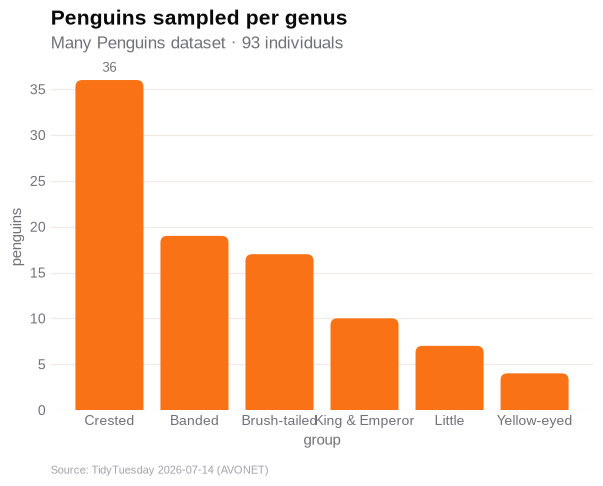

In [4]:
ax = viz.bar(
    df,
    x="group",
    sort="desc",
    title="Penguins sampled per genus",
    subtitle="Many Penguins dataset · 93 individuals",
    caption="Source: TidyTuesday 2026-07-14 (AVONET)",
    ylabel="penguins",
)
save(ax, "01_counts_by_genus.png")


### 2 · Mean wing length by species — horizontal bars

Eighteen species with long names read best **horizontally**. A ~3× spread runs from
the little penguin up to the emperor.

> **Note:** `viz.bar` *sums* `y` within each category (it's a magnitude chart), so for
> an **average** we pre-aggregate with pandas (`groupby().mean()`) and hand chartcn one
> row per group. Every "mean …" bar below does this.


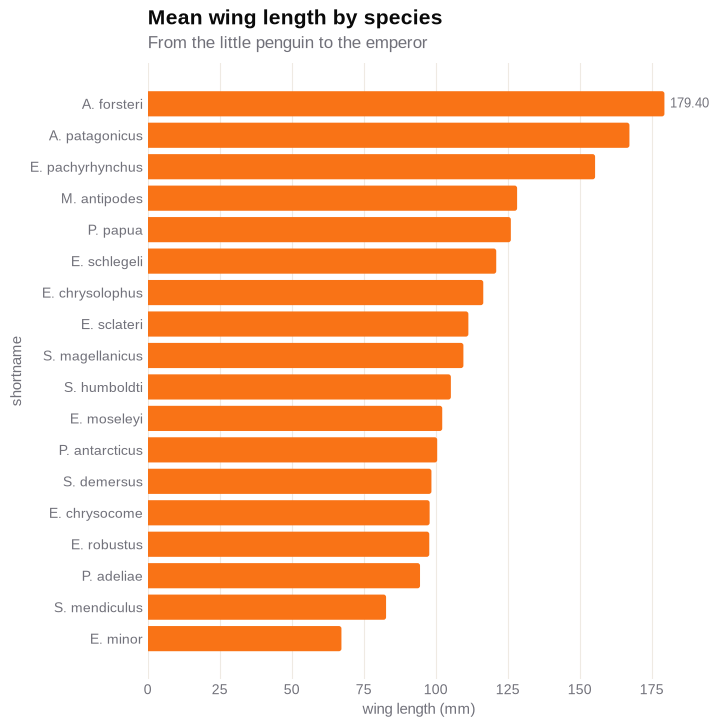

In [5]:
wing_by_species = (
    df.dropna(subset=["wing_length"])
      .groupby("shortname", as_index=False)["wing_length"].mean()
)

fig, ax = plt.subplots(figsize=(7, 8))  # taller canvas for 18 rows
viz.bar(
    wing_by_species,
    x="shortname",
    y="wing_length",
    horizontal=True,
    sort="desc",
    ax=ax,
    title="Mean wing length by species",
    subtitle="From the little penguin to the emperor",
    xlabel="wing length (mm)",
)
save(ax, "02_wing_by_species.png")


### 3 · Beak length by genus and sex — grouped bars

Passing `by="sex"` splits each genus into **grouped** bars with a frameless legend
(orange = female, black = male in the penguin palette). Unknown-sex birds are dropped.


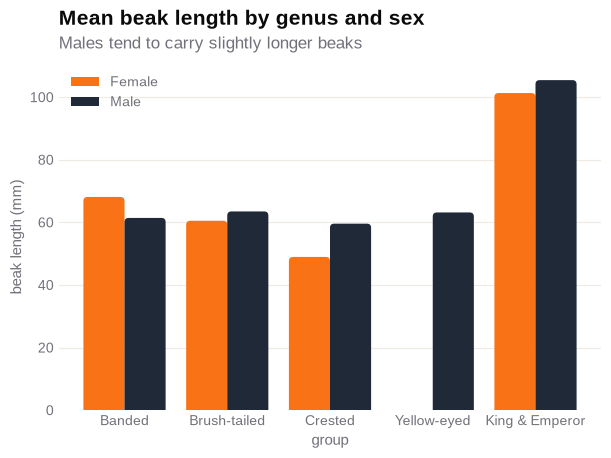

In [6]:
sexed = df[df["sex"].isin(["Male", "Female"])]

beak_gs = by_size(
    sexed.dropna(subset=["beak_length"])
         .groupby(["group", "sex"], as_index=False)["beak_length"].mean()
)

ax = viz.bar(
    beak_gs,
    x="group",
    y="beak_length",
    by="sex",
    title="Mean beak length by genus and sex",
    subtitle="Males tend to carry slightly longer beaks",
    ylabel="beak length (mm)",
)
save(ax, "03_beak_by_genus_sex.png")


### 4 · The giants — emphasis with `highlight=`

`highlight=` spotlights one group in the accent color and grays the rest (and drops
the legend). This is chartcn's answer to "make it clearer" — one color, not a rainbow.


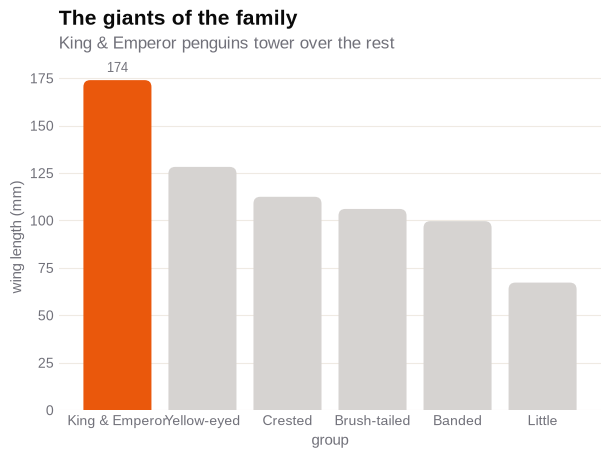

In [7]:
wing_genus = (
    df.dropna(subset=["wing_length"])
      .groupby("group", as_index=False)["wing_length"].mean()
)

ax = viz.bar(
    wing_genus,
    x="group",
    y="wing_length",
    sort="desc",
    highlight="King & Emperor",
    title="The giants of the family",
    subtitle="King & Emperor penguins tower over the rest",
    ylabel="wing length (mm)",
)
save(ax, "04_highlight_giants.png")


## Part 2 — relationships with scatters

Bars compare categories; to see how two *continuous* measurements move together we need
a **scatter**. (This is exactly where a line chart fails here — the penguins aren't an
ordered sequence, so connecting them would invent a trend.)

### 5 · Beak shape — a Simpson's paradox

Colored by genus, the pooled point cloud looks **flat** (overall r = −0.04). But the
per-genus best-fit lines — drawn with raw matplotlib on the `Axes` chartcn returns —
slope **upward inside most genera**. Longer beaks come with deeper beaks *within* a
group; the flat pooled trend is a classic **Simpson's paradox**.


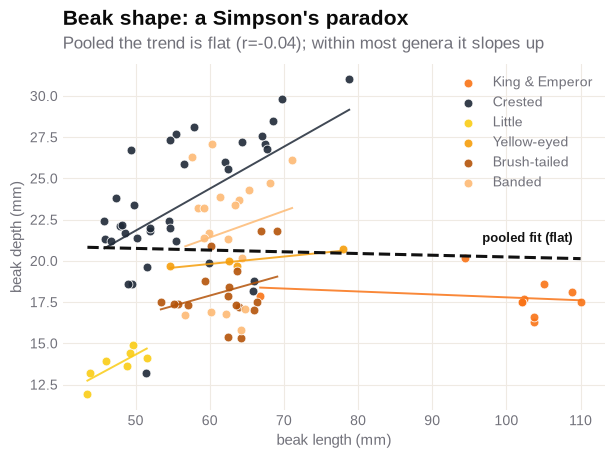

In [8]:
morph = df.dropna(subset=["beak_length", "beak_depth"])

ax = viz.scatter(
    morph,
    x="beak_length",
    y="beak_depth",
    by="group",
    title="Beak shape: a Simpson's paradox",
    subtitle="Pooled the trend is flat (r=-0.04); within most genera it slopes up",
    xlabel="beak length (mm)",
    ylabel="beak depth (mm)",
)

# Per-genus best-fit lines, matched to each genus's point color (read off the Axes).
for coll in ax.collections:
    d = morph[morph["group"] == coll.get_label()]
    if len(d) < 3:
        continue
    m, b = np.polyfit(d["beak_length"], d["beak_depth"], 1)
    xs = np.array([d["beak_length"].min(), d["beak_length"].max()])
    ax.plot(xs, m * xs + b, color=coll.get_facecolor()[0], lw=1.4, alpha=0.85, zorder=2)

# The misleading pooled fit (flat) as a dashed reference line.
m, b = np.polyfit(morph["beak_length"], morph["beak_depth"], 1)
xs = np.array([morph["beak_length"].min(), morph["beak_length"].max()])
ax.plot(xs, m * xs + b, color="#111111", lw=2.2, ls="--", zorder=4)
ax.annotate(
    "pooled fit (flat)",
    xy=(xs[1], m * xs[1] + b),
    xytext=(-6, 12),
    textcoords="offset points",
    ha="right",
    color="#111111",
    fontsize=9,
    fontweight="bold",
)
save(ax, "05_beak_morphospace.png")


### 6 · Everything scales together — allometry (bubble scatter)

A second scatter maps a **third** dimension to bubble size via `size=`. Beak length vs
wing length (r ≈ 0.69), with bubble area = leg (tarsus) length: bigger penguins are
bigger *everywhere*, and the genera stack along the shared size axis.


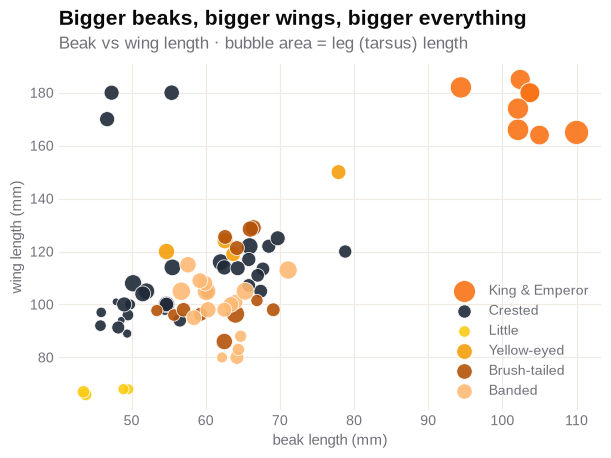

In [9]:
allo = df.dropna(subset=["beak_length", "wing_length", "tarsus_length"])

ax = viz.scatter(
    allo,
    x="beak_length",
    y="wing_length",
    by="group",
    size="tarsus_length",
    title="Bigger beaks, bigger wings, bigger everything",
    subtitle="Beak vs wing length · bubble area = leg (tarsus) length",
    xlabel="beak length (mm)",
    ylabel="wing length (mm)",
)
save(ax, "06_allometry_bubble.png")


## Part 3 — a distribution with a histogram

### 7 · Two kinds of beak

A histogram shows the *shape* of a single trait. Beak length is **bimodal**: a broad
cluster of small-to-mid species, a gap, then a separate cluster of giants past ~85 mm.


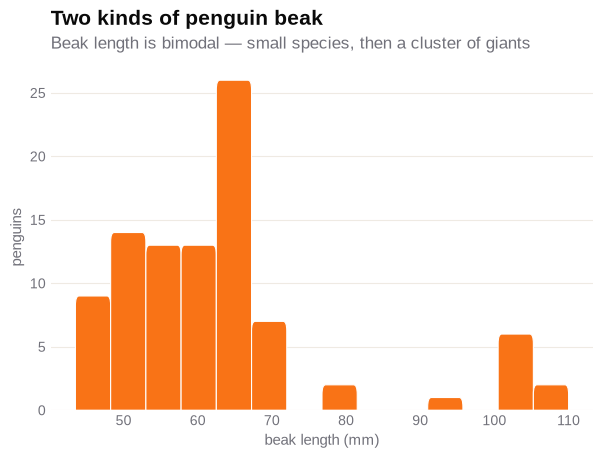

In [10]:
ax = viz.hist(
    df,
    x="beak_length",
    bins=14,
    title="Two kinds of penguin beak",
    subtitle="Beak length is bimodal — small species, then a cluster of giants",
    xlabel="beak length (mm)",
    ylabel="penguins",
)
save(ax, "07_beak_distribution.png")


### 8 · Bonus — the texture channel for black-and-white

`texture=True` adds a hatch pattern per series, so a grouped chart stays legible when
printed in grayscale or seen by colorblind readers — a secondary encoding on top of color.


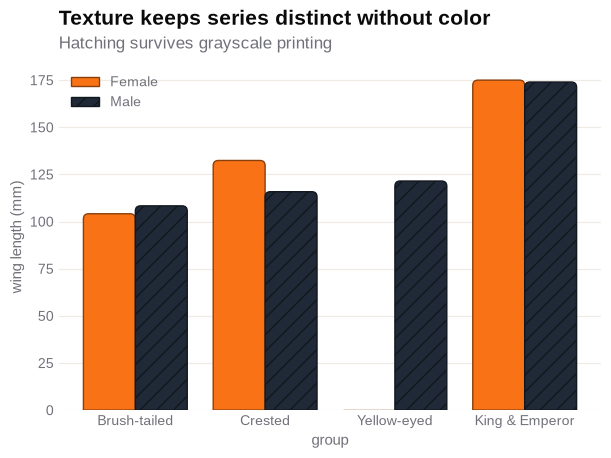

In [11]:
wing_gs = by_size(
    sexed.dropna(subset=["wing_length"])
         .groupby(["group", "sex"], as_index=False)["wing_length"].mean()
)

ax = viz.bar(
    wing_gs,
    x="group",
    y="wing_length",
    by="sex",
    texture=True,
    title="Texture keeps series distinct without color",
    subtitle="Hatching survives grayscale printing",
    ylabel="wing length (mm)",
)
save(ax, "08_texture_bw.png")


## Takeaways

- **Match the chart to the question.** Bars compare categories, scatters show how two
  continuous traits relate, histograms show a distribution's shape. A line was the
  wrong tool here — there's no ordered x-axis to justify one.
- **One call per chart, from a DataFrame** — with good defaults: rounded bars, no
  spines, a faint grid, selective labels, and a frameless legend only for ≥ 2 series.
- **Emphasis over rainbow** (`highlight=`), a **third dimension** via `size=`, and an
  opt-in **texture** channel for accessibility.
- **Never a dead end:** the Simpson's-paradox trend lines are plain matplotlib drawn on
  the `Axes` chartcn hands back — no library changes needed.
- A brand palette is just `dataclasses.replace(viz.LIGHT, ...)`.

**The story:** penguins get bigger from the little penguin to the emperor, and every
trait scales with body size — but beak length and depth only track together *within*
a genus, not across the family (Simpson's paradox), and beak length splits the family
into two clusters: the many small species and the few giants.
